<a href="https://colab.research.google.com/github/0987-k123/Machine-Learning-Project/blob/main/ML_Practical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Design a simple machine learning model to train the training instances and test
the same.

In [ ]:
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Load dataset
iris = load_iris()

# 2. Create DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

print("Dataset:")
print(df.head())

# 3. Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# 4. Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("\nTraining records:", len(X_train))
print("Testing records:", len(X_test))

# 5. Create model
model = DecisionTreeClassifier(random_state=42)

# 6. Train model
model.fit(X_train, y_train)

# 7. Test model
y_pred = model.predict(X_test)

# 8. Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nPredictions:")
print(y_pred)

print("\nActual:")
print(y_test.values)

print("\nAccuracy:", accuracy * 100, "%")

# 9. Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 10. New prediction
new_instance = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(new_instance)

print("New Instance Prediction:",
      iris.target_names[prediction[0]])

Dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Training records: 120
Testing records: 30

Predictions:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]

Actual:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]

Accuracy: 100.0 %

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00     

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


 Implement and demonstrate the FIND-S algorithm for finding the most specific
hypothesis based on a given set of training data samples. Read the training data from a .CSV
file

In [ ]:
import pandas as pd
from google.colab import files

# Upload CSV file
uploaded = files.upload()

# Read CSV
filename = list(uploaded.keys())[0]
data = pd.read_csv(filename)

print("Training Data:")
print(data)

# FIND-S Algorithm
def find_s(data):

    # Separate attributes and target
    attributes = data.iloc[:, :-1]
    target = data.iloc[:, -1]

    # Initialize most specific hypothesis
    hypothesis = ['0'] * attributes.shape[1]

    # Process every training example
    for i in range(len(data)):

        # Check whether example is positive
        if target.iloc[i] == 'Yes':

            for j in range(attributes.shape[1]):

                # First positive example
                if hypothesis[j] == '0':
                    hypothesis[j] = attributes.iloc[i, j]

                # Different values -> generalize
                elif hypothesis[j] != attributes.iloc[i, j]:
                    hypothesis[j] = '?'

    return hypothesis


# Apply FIND-S
hypothesis = find_s(data)

print("\nMost Specific Hypothesis:")
print(hypothesis)

Saving ai_impact_jobs_2010_2025.csv to ai_impact_jobs_2010_2025.csv
Training Data:
                                    job_id  posting_year    country  \
0     836b4774-702e-49ef-93d3-2f255ce1e910          2018     Brazil   
1     43699e93-7b15-4728-a4c6-9e41ff438a25          2015        UAE   
2     fc9d1854-3cbf-4bab-90df-77304dfc59df          2016      Nepal   
3     05c1c7d3-2add-4919-91eb-f6c78bfe23d1          2015      Spain   
4     5e739937-d1b0-44d7-935c-7ebb3fc1f6e8          2014     Taiwan   
...                                    ...           ...        ...   
4995  45aa223b-3ed6-4574-bd07-294a1443c02b          2022  Singapore   
4996  9f69f4ce-5fe9-44db-9541-478ebe28422b          2018      Chile   
4997  0ec6f97e-6dc3-468c-b2a2-ecc087bf067e          2019  Australia   
4998  ad529cef-b22e-4e7d-82fd-98fc06d61596          2016     Sweden   
4999  79d26161-8cc1-4d98-ab0d-3ebea91f2a1b          2024      India   

              region       city          company_name company_si

Perform Data Loading, Feature selection (Principal Component analysis) and
Feature Scoring and Ranking

In [ ]:
import pandas as pd
from google.colab import files
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ==========================================
# 1. DATA LOADING
# ==========================================

uploaded = files.upload()

filename = list(uploaded.keys())[0]
data = pd.read_csv(filename)

print("========== DATASET ==========")
print(data.head())

print("\nDataset Shape:", data.shape)


# ==========================================
# 2. FEATURE SELECTION
# ==========================================

# Last column is considered target
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Convert categorical features to numerical
X = pd.get_dummies(X, drop_first=True)

print("\nNumber of Features:", X.shape[1])


# ==========================================
# 3. STANDARDIZATION
# ==========================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nData Standardization Completed")


# ==========================================
# 4. PRINCIPAL COMPONENT ANALYSIS
# ==========================================

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

print("\nPCA Completed")
print("Number of Components:", pca.n_components_)

scores = pca.explained_variance_ratio_

print("\n========== FEATURE SCORES ==========")

for i, score in enumerate(scores):
    print(f"PC{i+1}: {score:.4f}")


ranking = pd.DataFrame({
    'Principal Component':
        [f'PC{i+1}' for i in range(len(scores))],

    'Score':
        scores
})

ranking['Percentage'] = ranking['Score'] * 100

ranking = ranking.sort_values(
    by='Score',
    ascending=False
)

print("\n========== FEATURE RANKING ==========")
print(ranking)


pca_95 = PCA(n_components=0.95)

X_selected = pca_95.fit_transform(X_scaled)

print("\n========== FINAL RESULT ==========")

print("Original Features:", X.shape[1])

print("Selected Components:", X_selected.shape[1])

print("Variance Retained:",
      sum(pca_95.explained_variance_ratio_) * 100, "%")

Saving diabetes_prediction_dataset.csv.zip to diabetes_prediction_dataset.csv.zip
========== DATASET ==========
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  

Dataset Shape: (100000, 9)

Number of Features: 13

Data Standardization Completed

PCA Completed
Number of Components: 13

========== FEATURE SCORES ==========
PC1: 0.1392

 For a given set of training data examples stored in a .CSV file, implement and
demonstrate the Candidate-Elimination algorithm to output a description of the set of all
hypotheses consistent with the training examples.

In [ ]:
import pandas as pd
from google.colab import files

# Upload CSV file
uploaded = files.upload()

# Read CSV
filename = list(uploaded.keys())[0]
data = pd.read_csv(filename)

print("Training Data:")
print(data)

# ---------------------------------------------------
# Candidate Elimination Algorithm
# ---------------------------------------------------

def candidate_elimination(data):

    attributes = data.iloc[:, :-1].values
    target = data.iloc[:, -1].values

    n_attributes = attributes.shape[1]

    # Most specific hypothesis
    S = ['0'] * n_attributes

    # Most general hypothesis
    G = [['?'] * n_attributes]

    for i in range(len(data)):

        example = attributes[i]

        # Positive example
        if target[i] == 'Yes':

            # Remove G hypotheses that don't cover example
            G = [
                g for g in G
                if all(g[j] == '?' or g[j] == example[j]
                       for j in range(n_attributes))
            ]

            # Generalize S
            for j in range(n_attributes):

                if S[j] == '0':
                    S[j] = example[j]

                elif S[j] != example[j]:
                    S[j] = '?'

            # Remove G hypotheses that are more specific
            # than S
            new_G = []

            for g in G:
                if all(
                    g[j] == '?' or g[j] == S[j]
                    for j in range(n_attributes)
                ):
                    new_G.append(g)

            G = new_G

        # Negative example
        else:

            # Remove hypotheses from G that don't cover
            # the negative example
            new_G = []

            for g in G:

                if all(
                    g[j] == '?' or g[j] == example[j]
                    for j in range(n_attributes)
                ):

                    # Specialize G
                    for j in range(n_attributes):

                        if g[j] == '?':
                            if S[j] != '?' and S[j] != '0':
                                new_hypothesis = g.copy()
                                new_hypothesis[j] = S[j]
                                new_G.append(new_hypothesis)

                else:
                    new_G.append(g)

            G = new_G

    return S, G


# Run algorithm
S, G = candidate_elimination(data)

# ---------------------------------------------------
# Display Result
# ---------------------------------------------------

print("\n================================")
print("Candidate-Elimination Result")
print("================================")

print("\nSpecific Boundary (S):")
print(S)

print("\nGeneral Boundary (G):")

for hypothesis in G:
    print(hypothesis)

Saving diabetes_prediction_dataset.csv.zip to diabetes_prediction_dataset.csv (1).zip
Training Data:
       gender   age  hypertension  heart_disease smoking_history    bmi  \
0      Female  80.0             0              1           never  25.19   
1      Female  54.0             0              0         No Info  27.32   
2        Male  28.0             0              0           never  27.32   
3      Female  36.0             0              0         current  23.45   
4        Male  76.0             1              1         current  20.14   
...       ...   ...           ...            ...             ...    ...   
99995  Female  80.0             0              0         No Info  27.32   
99996  Female   2.0             0              0         No Info  17.37   
99997    Male  66.0             0              0          former  27.83   
99998  Female  24.0             0              0           never  35.42   
99999  Female  57.0             0              0         current  22.43   

### Naive Bayesian Classifier Implementation

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB # GaussianNB for continuous features
from sklearn.metrics import accuracy_score, classification_report
from google.colab import files

# 1. Upload CSV file for training data
print("Please upload your training data CSV file.")
uploaded_train = files.upload()


filename_train = list(uploaded_train.keys())[0]
training_data = pd.read_csv(filename_train)

print("\nTraining Data Head:")
display(training_data.head())

X = training_data.iloc[:, :-1]
y = training_data.iloc[:, -1]

X = pd.get_dummies(X, drop_first=True)

print(f"\nFeatures shape after one-hot encoding: {X.shape}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"\nTraining features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

model = GaussianNB()
model.fit(X_train, y_train)

print("\nNaive Bayesian model trained successfully.")

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy of the classifier: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nSample Predictions vs. Actual (first 10 test samples):")
for i in range(10):
    print(f"Predicted: {y_pred[i]}, Actual: {y_test.iloc[i]}")

Please upload your training data CSV file.


Saving ai_impact_jobs_2010_2025.csv to ai_impact_jobs_2010_2025.csv

Training Data Head:


,job_id,posting_year,country,region,city,company_name,company_size,industry,job_title,seniority_level,...,ai_intensity_score,core_skills,ai_skills,salary_usd,salary_change_vs_prev_year_percent,automation_risk_score,reskilling_required,ai_job_displacement_risk,job_description_embedding_cluster,industry_ai_adoption_stage
0,836b4774-702e-49ef-93d3-2f255ce1e910,2018,Brazil,South America,London,NextGen Technologies,Small,Education,Policy Analyst,Lead,...,0.81,"Research, Project Management, Business Analysis",reinforcement learning,61586,12.68,0.11,True,Low,14,Growing
1,43699e93-7b15-4728-a4c6-9e41ff438a25,2015,UAE,Middle East,Singapore,Future Solutions,Medium,Energy,Data Scientist,Executive,...,0.04,"Research, SQL, Business Analysis, Python, Clou...",NaN,62045,-3.98,0.71,False,High,19,Emerging
2,fc9d1854-3cbf-4bab-90df-77304dfc59df,2016,Nepal,South Asia,Sydney,Future Analytics,Startup,Finance,Product Manager,Junior,...,0.15,"Statistics, Project Management, Cloud Computin...",NaN,27035,3.55,0.86,False,High,2,Emerging
3,05c1c7d3-2add-4919-91eb-f6c78bfe23d1,2015,Spain,Europe,Nairobi,Global Technologies,Large,Government,Data Scientist,Mid,...,0.19,"Cloud Computing, SQL, Project Management, Comm...",NaN,72894,-2.80,0.70,False,Low,15,Emerging
4,5e739937-d1b0-44d7-935c-7ebb3fc1f6e8,2014,Taiwan,East Asia,Sydney,Future Technologies,Small,Manufacturing,ML Engineer,Lead,...,0.11,"SQL, Python, Communication, Software Engineeri...",NaN,57215,0.85,0.87,False,High,13,Emerging



Features shape after one-hot encoding: (5000, 10507)

Training features shape: (3500, 10507)
Testing features shape: (1500, 10507)

Naive Bayesian model trained successfully.

Accuracy of the classifier: 0.8627

Classification Report:
              precision    recall  f1-score   support

    Emerging       0.86      0.99      0.92       650
     Growing       0.90      0.82      0.86       753
      Mature       0.51      0.39      0.44        97

    accuracy                           0.86      1500
   macro avg       0.76      0.73      0.74      1500
weighted avg       0.86      0.86      0.86      1500


Sample Predictions vs. Actual (first 10 test samples):
Predicted: Emerging, Actual: Emerging
Predicted: Growing, Actual: Growing
Predicted: Emerging, Actual: Emerging
Predicted: Emerging, Actual: Emerging
Predicted: Growing, Actual: Growing
Predicted: Growing, Actual: Growing
Predicted: Emerging, Actual: Growing
Predicted: Emerging, Actual: Emerging
Predicted: Emerging, Actual: E

### Decision Tree Classifier Implementation

Decision Tree model trained successfully.

Decision Tree Classifier Accuracy: 1.0000

Decision Tree Classification Report:
              precision    recall  f1-score   support

    Emerging       1.00      1.00      1.00       650
     Growing       1.00      1.00      1.00       753
      Mature       1.00      1.00      1.00        97

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500



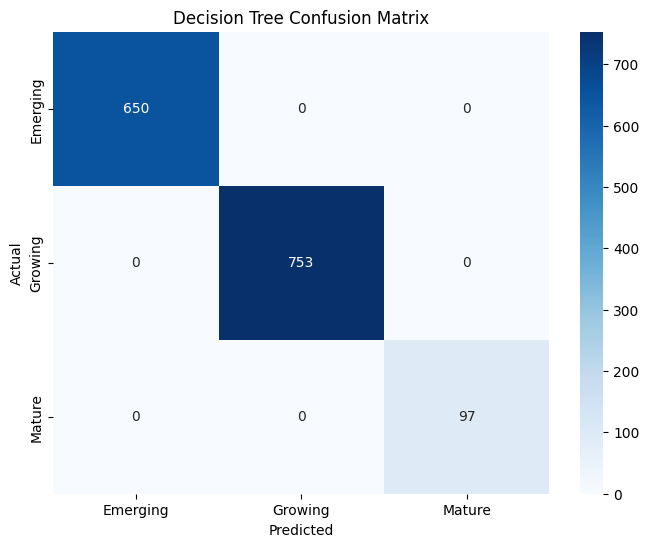

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Initialize the Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)

# 2. Train the model
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

# 3. Make predictions on the test set
y_pred_dt = dt_model.predict(X_test)

# 4. Evaluate the classifier
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"\nDecision Tree Classifier Accuracy: {accuracy_dt:.4f}")

print("\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))

# 5. Display Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=dt_model.classes_, yticklabels=dt_model.classes_)
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Random Forest Classifier Implementation

Random Forest model trained successfully.

Random Forest Classifier Accuracy: 0.9367

Random Forest Classification Report:
              precision    recall  f1-score   support

    Emerging       1.00      1.00      1.00       650
     Growing       0.89      1.00      0.94       753
      Mature       1.00      0.02      0.04        97

    accuracy                           0.94      1500
   macro avg       0.96      0.67      0.66      1500
weighted avg       0.94      0.94      0.91      1500



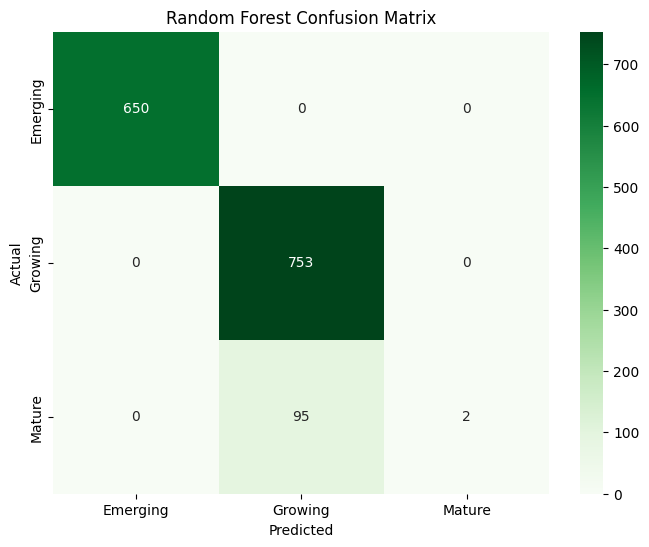

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)

# 2. Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

# 3. Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# 4. Evaluate the classifier
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nRandom Forest Classifier Accuracy: {accuracy_rf:.4f}")

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# 5. Display Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Least Squares Regression Implementation

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from google.colab import files
import numpy as np

# 1. Upload CSV file for training data
print("Please upload your CSV file for Least Squares Regression.")
uploaded_regression = files.upload()

# Get the filename of the uploaded CSV
filename_regression = list(uploaded_regression.keys())[0]
regression_data = pd.read_csv(filename_regression)

print("\nRegression Data Head:")
display(regression_data.head())

# 2. Separate features (X) and target (y)
# Assuming the last column is the target (dependent) variable for regression
# Ensure the target variable is numerical.
X_reg = regression_data.iloc[:, :-1]
y_reg = regression_data.iloc[:, -1]

# Handle categorical features by one-hot encoding if any
X_reg = pd.get_dummies(X_reg, drop_first=True)

# Ensure the target variable is numeric
if not pd.api.types.is_numeric_dtype(y_reg):
    try:
        y_reg = pd.to_numeric(y_reg)
        print("\nTarget variable converted to numeric type.")
    except ValueError:
        print("\nError: Target variable is not numeric and cannot be converted. Please ensure the last column is a continuous numerical variable.")
        # You might want to halt execution or handle this error more gracefully
        exit()

print(f"\nFeatures shape after one-hot encoding: {X_reg.shape}")

# 3. Split data into training and testing sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

print(f"\nTraining features shape: {X_train_reg.shape}")
print(f"Testing features shape: {X_test_reg.shape}")

# 4. Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train_reg, y_train_reg)

print("\nLeast Squares Regression model trained successfully.")
print(f"Intercept: {linear_model.intercept_:.2f}")
print("Coefficients:")
for feature, coef in zip(X_reg.columns, linear_model.coef_):
    print(f"  {feature}: {coef:.2f}")

# 5. Make predictions on the test set
y_pred_reg = linear_model.predict(X_test_reg)

# 6. Evaluate the model
mse = mean_squared_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"\nMean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")

# Optional: Display some predictions vs actuals
print("\nSample Predictions vs. Actual (first 10 test samples):")
for i in range(10):
    print(f"Predicted: {y_pred_reg[i]:.2f}, Actual: {y_test_reg.iloc[i]:.2f}")

Please upload your CSV file for Least Squares Regression.


Saving diabetes_prediction_dataset.csv.zip to diabetes_prediction_dataset.csv.zip

Regression Data Head:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0



Features shape after one-hot encoding: (100000, 13)

Training features shape: (70000, 13)
Testing features shape: (30000, 13)

Least Squares Regression model trained successfully.
Intercept: -0.87
Coefficients:
  age: 0.00
  hypertension: 0.09
  heart_disease: 0.12
  bmi: 0.00
  HbA1c_level: 0.08
  blood_glucose_level: 0.00
  gender_Male: 0.01
  gender_Other: -0.05
  smoking_history_current: 0.01
  smoking_history_ever: 0.01
  smoking_history_former: 0.03
  smoking_history_never: 0.01
  smoking_history_not current: 0.02

Mean Squared Error (MSE): 0.0510
R-squared (R2) Score: 0.3439

Sample Predictions vs. Actual (first 10 test samples):
Predicted: -0.01, Actual: 0.00
Predicted: -0.04, Actual: 0.00
Predicted: 0.10, Actual: 0.00
Predicted: -0.01, Actual: 0.00
Predicted: 0.31, Actual: 1.00
Predicted: 0.32, Actual: 0.00
Predicted: 0.09, Actual: 0.00
Predicted: 0.01, Actual: 0.00
Predicted: 0.14, Actual: 0.00
Predicted: 0.00, Actual: 0.00


### Logistic Regression Algorithm Implementation

Please upload your CSV file for Logistic Regression.


Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition.csv

Logistic Regression Data Head:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2



Features shape after one-hot encoding: (1470, 47)

Training features shape: (1029, 47)
Testing features shape: (441, 47)


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no pre


Logistic Regression model trained successfully.

Accuracy of the Logistic Regression classifier: 0.2245

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.25      0.16      0.20        75
           1       0.00      0.00      0.00        19
           2       0.25      0.83      0.38        96
           3       0.00      0.00      0.00        43
           4       0.00      0.00      0.00        27
           5       0.00      0.00      0.00         5
           6       0.00      0.00      0.00        12
           7       0.17      0.09      0.11        81
           8       0.00      0.00      0.00        31
           9       0.00      0.00      0.00        17
          10       0.00      0.00      0.00         9
          11       0.00      0.00      0.00         6
          12       0.00      0.00      0.00         6
          13       0.00      0.00      0.00         7
          14       0.00      0.00      0

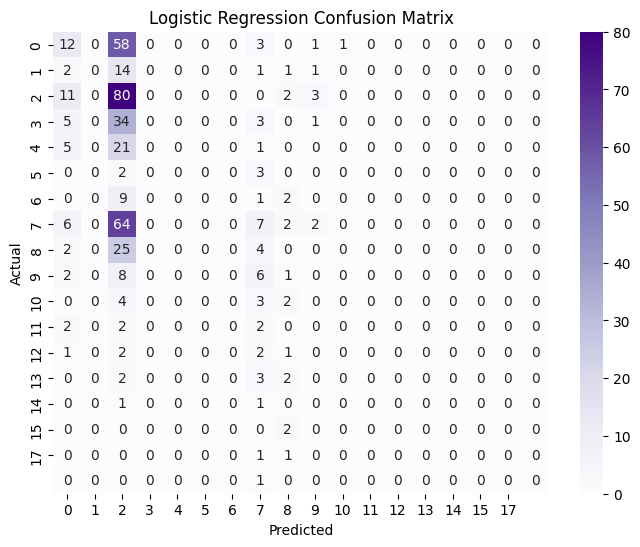

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from google.colab import files
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Upload CSV file for training data
print("Please upload your CSV file for Logistic Regression.")
uploaded_logistic = files.upload()

# Get the filename of the uploaded CSV
filename_logistic = list(uploaded_logistic.keys())[0]
logistic_data = pd.read_csv(filename_logistic)

print("\nLogistic Regression Data Head:")
display(logistic_data.head())


X_log = logistic_data.iloc[:, :-1]
y_log = logistic_data.iloc[:, -1]

X_log = pd.get_dummies(X_log, drop_first=True)

if not pd.api.types.is_numeric_dtype(y_log):
    try:
        y_log = pd.Categorical(y_log).codes # Converts categories to numerical labels
        print("\nTarget variable converted to numerical labels.")
    except Exception as e:
        print(f"\nError: Target variable is not suitable for classification. {e}")
        exit()

print(f"\nFeatures shape after one-hot encoding: {X_log.shape}")

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log, y_log, test_size=0.3, random_state=42)

print(f"\nTraining features shape: {X_train_log.shape}")
print(f"Testing features shape: {X_test_log.shape}")

# 4. Initialize and train the Logistic Regression model
# max_iter is increased to ensure convergence for larger datasets
logistic_model = LogisticRegression(random_state=42, max_iter=1000)
logistic_model.fit(X_train_log, y_train_log)

print("\nLogistic Regression model trained successfully.")

# 5. Make predictions on the test set
y_pred_log = logistic_model.predict(X_test_log)

# 6. Evaluate the model
accuracy_log = accuracy_score(y_test_log, y_pred_log)
print(f"\nAccuracy of the Logistic Regression classifier: {accuracy_log:.4f}")

print("\nLogistic Regression Classification Report:")
print(classification_report(y_test_log, y_pred_log))

# 7. Display Confusion Matrix
cm_log = confusion_matrix(y_test_log, y_pred_log)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Purples',
            xticklabels=logistic_model.classes_, yticklabels=logistic_model.classes_)
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Write a program to demonstrate the working of the decision tree based ID3 algorithm. Use an appropriate data set for building the decision tree and apply this knowledge to classify a new sample.

In [ ]:
# Decision Tree using ID3 Algorithm
# Dataset: Play Tennis

import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, export_text

# Create the dataset
data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain',
                'Overcast', 'Sunny', 'Sunny', 'Rain', 'Sunny', 'Overcast',
                'Overcast', 'Rain'],

    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool',
                    'Cool', 'Mild', 'Cool', 'Mild', 'Mild', 'Mild',
                    'Hot', 'Mild'],

    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal',
                 'Normal', 'High', 'Normal', 'Normal', 'Normal', 'High',
                 'Normal', 'High'],

    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong',
             'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong',
             'Weak', 'Strong'],

    'PlayTennis': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No',
                   'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes',
                   'Yes', 'No']
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)

# Encode categorical values into numbers
encoders = {}

for column in df.columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    encoders[column] = le

# Separate features and target
X = df.drop('PlayTennis', axis=1)
y = df['PlayTennis']

# Create Decision Tree using ID3
model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

# Train the model
model.fit(X, y)

# Display the decision tree rules
print("\nDecision Tree Rules:")
tree_rules = export_text(
    model,
    feature_names=list(X.columns)
)

print(tree_rules)

# Create a new sample
new_sample = pd.DataFrame({
    'Outlook': ['Sunny'],
    'Temperature': ['Cool'],
    'Humidity': ['High'],
    'Wind': ['Strong']
})

# Encode the new sample using the same encoders
for column in new_sample.columns:
    new_sample[column] = encoders[column].transform(new_sample[column])

# Predict the class
prediction = model.predict(new_sample)

# Convert prediction back to original label
result = encoders['PlayTennis'].inverse_transform(prediction)

print("\nNew Sample:")
print("Outlook = Sunny, Temperature = Cool, Humidity = High, Wind = Strong")

print("\nPredicted Class:", result[0])

Dataset:
     Outlook Temperature Humidity    Wind PlayTennis
0      Sunny         Hot     High    Weak         No
1      Sunny         Hot     High  Strong         No
2   Overcast         Hot     High    Weak        Yes
3       Rain        Mild     High    Weak        Yes
4       Rain        Cool   Normal    Weak        Yes
5       Rain        Cool   Normal  Strong         No
6   Overcast        Cool   Normal  Strong        Yes
7      Sunny        Mild     High    Weak         No
8      Sunny        Cool   Normal    Weak        Yes
9       Rain        Mild   Normal    Weak        Yes
10     Sunny        Mild   Normal  Strong        Yes
11  Overcast        Mild     High  Strong        Yes
12  Overcast         Hot   Normal    Weak        Yes
13      Rain        Mild     High  Strong         No

Decision Tree Rules:
|--- Outlook <= 0.50
|   |--- class: 1
|--- Outlook >  0.50
|   |--- Humidity <= 0.50
|   |   |--- Outlook <= 1.50
|   |   |   |--- Wind <= 0.50
|   |   |   |   |--- class: 0

### k-Nearest Neighbors (KNN) Classifier Implementation

Iris Dataset Features (first 5 rows):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Iris Dataset Target (first 5 rows):


,0
0,0
1,0
2,0
3,0
4,0



Training features shape: (105, 4)
Testing features shape: (45, 4)

k-Nearest Neighbors model trained successfully with Euclidean distance.

Accuracy of the KNN classifier: 1.0000

KNN Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



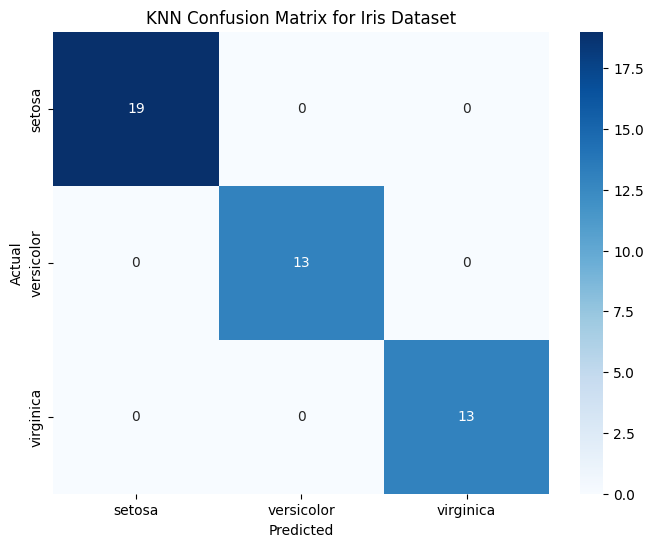


Sample Predictions vs. Actual (first 10 test samples):
Predicted: versicolor, Actual: versicolor
Predicted: setosa, Actual: setosa
Predicted: virginica, Actual: virginica
Predicted: versicolor, Actual: versicolor
Predicted: versicolor, Actual: versicolor
Predicted: setosa, Actual: setosa
Predicted: versicolor, Actual: versicolor
Predicted: virginica, Actual: virginica
Predicted: versicolor, Actual: versicolor
Predicted: versicolor, Actual: versicolor


In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the Iris dataset
iris = load_iris()
X_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
y_iris = pd.Series(iris.target)

print("Iris Dataset Features (first 5 rows):")
display(X_iris.head())
print("Iris Dataset Target (first 5 rows):")
display(y_iris.head())

# 2. Split data into training and testing sets
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris,
    test_size=0.3, # 30% for testing
    random_state=42 # for reproducibility
)

print(f"\nTraining features shape: {X_train_iris.shape}")
print(f"Testing features shape: {X_test_iris.shape}")

# 3. Initialize and train the KNN model
# Using 'euclidean' distance, which is the default for p=2 in Minkowski metric
knn_model = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_model.fit(X_train_iris, y_train_iris)

print("\nk-Nearest Neighbors model trained successfully with Euclidean distance.")

# 4. Make predictions on the test set
y_pred_iris = knn_model.predict(X_test_iris)

# 5. Evaluate the model
accuracy_iris = accuracy_score(y_test_iris, y_pred_iris)
print(f"\nAccuracy of the KNN classifier: {accuracy_iris:.4f}")

print("\nKNN Classification Report:")
print(classification_report(y_test_iris, y_pred_iris, target_names=iris.target_names))

# 6. Display Confusion Matrix
cm_iris = confusion_matrix(y_test_iris, y_pred_iris)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_iris, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('KNN Confusion Matrix for Iris Dataset')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nSample Predictions vs. Actual (first 10 test samples):")
for i in range(10):
    print(f"Predicted: {iris.target_names[y_pred_iris[i]]}, Actual: {iris.target_names[y_test_iris.iloc[i]]}")

Implement the different Distance methods (Euclidean) with Prediction, Test Score and Confusion Matrix.

### Classification using K-Means Clustering

Iris Dataset Features (first 5 rows):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Iris Dataset Target (first 5 rows):


,0
0,0
1,0
2,0
3,0
4,0



Training features shape: (105, 4)
Testing features shape: (45, 4)

K-Means clustering applied to training data.

Cluster to Class Mapping: {0: np.int64(2), 1: np.int64(0), 2: np.int64(1)}

K-Means based predictions generated for the test set.

Accuracy of K-Means based classifier: 0.9333

K-Means Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       0.81      1.00      0.90        13
   virginica       1.00      0.77      0.87        13

    accuracy                           0.93        45
   macro avg       0.94      0.92      0.92        45
weighted avg       0.95      0.93      0.93        45



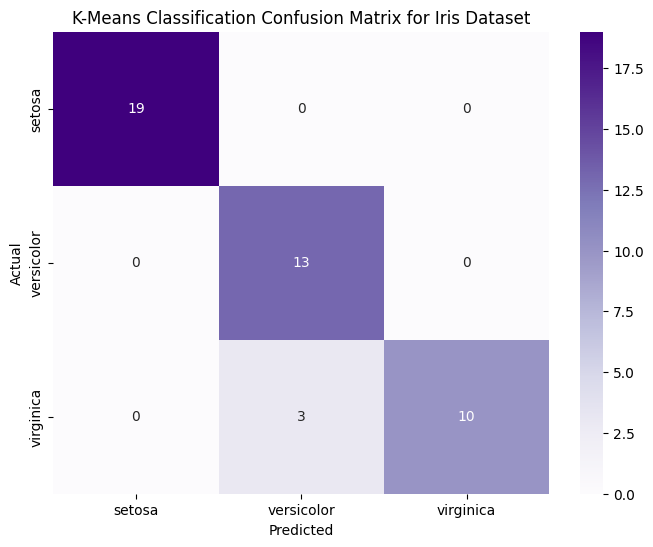


Sample Predictions vs. Actual (first 10 test samples):
Predicted: versicolor, Actual: versicolor
Predicted: setosa, Actual: setosa
Predicted: virginica, Actual: virginica
Predicted: versicolor, Actual: versicolor
Predicted: versicolor, Actual: versicolor
Predicted: setosa, Actual: setosa
Predicted: versicolor, Actual: versicolor
Predicted: virginica, Actual: virginica
Predicted: versicolor, Actual: versicolor
Predicted: versicolor, Actual: versicolor


In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the Iris dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)

print("Iris Dataset Features (first 5 rows):")
display(X.head())
print("Iris Dataset Target (first 5 rows):")
display(y.head())

# 2. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3, # 30% for testing
    random_state=42 # for reproducibility
)

print(f"\nTraining features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

# 3. Apply K-Means clustering to the training data
# We know there are 3 classes in the Iris dataset, so n_clusters=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # n_init for robust centroid initialization
kmeans.fit(X_train)

print("\nK-Means clustering applied to training data.")

# 4. Map cluster labels to actual class labels
# This step is crucial for using clustering for classification
def map_clusters_to_classes(kmeans_labels, true_labels, n_clusters):
    # Create a dictionary to store the mapping
    cluster_to_class_map = {}

    # Iterate through each cluster
    for i in range(n_clusters):
        # Get the indices of samples belonging to the current cluster
        cluster_indices = np.where(kmeans_labels == i)
        # Get the true labels for these samples
        true_labels_in_cluster = true_labels.iloc[cluster_indices]
        # Find the most frequent true label in this cluster
        if not true_labels_in_cluster.empty:
            most_common_class = true_labels_in_cluster.mode()[0]
            cluster_to_class_map[i] = most_common_class
        else:
            # Handle empty clusters if necessary, e.g., assign a default or skip
            cluster_to_class_map[i] = -1 # Or some other indicator for an unmapped cluster
    return cluster_to_class_map

# Get K-Means predicted clusters for training data
y_train_clusters = kmeans.labels_

# Perform the mapping
cluster_class_mapping = map_clusters_to_classes(y_train_clusters, y_train, 3)
print(f"\nCluster to Class Mapping: {cluster_class_mapping}")

# 5. Make predictions on the test set
y_test_clusters = kmeans.predict(X_test)
y_pred_kmeans = np.array([cluster_class_mapping.get(cluster_id, -1) for cluster_id in y_test_clusters])

print("\nK-Means based predictions generated for the test set.")

# 6. Evaluate the model
accuracy_kmeans = accuracy_score(y_test, y_pred_kmeans)
print(f"\nAccuracy of K-Means based classifier: {accuracy_kmeans:.4f}")

print("\nK-Means Classification Report:")
print(classification_report(y_test, y_pred_kmeans, target_names=iris.target_names))

# 7. Display Confusion Matrix
cm_kmeans = confusion_matrix(y_test, y_pred_kmeans)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_kmeans, annot=True, fmt='d', cmap='Purples',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('K-Means Classification Confusion Matrix for Iris Dataset')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nSample Predictions vs. Actual (first 10 test samples):")
for i in range(10):
    print(f"Predicted: {iris.target_names[y_pred_kmeans[i]]}, Actual: {iris.target_names[y_test.iloc[i]]}")

Dataset Shape: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']

Predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]

Actual Values:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]

New Sample: [[5.1, 3.5, 1.4, 0.2]]
Predicted Class: setosa

Test Score: 1.0
Test Accuracy: 100.00%

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


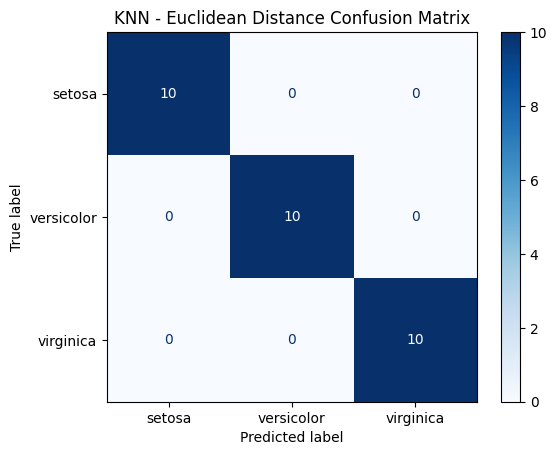


Accuracy Score: 1.0
Accuracy: 100.00%


In [ ]:
# Implement Euclidean Distance using KNN
# Prediction, Test Score and Confusion Matrix

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

iris = load_iris()

X = iris.data
y = iris.target

print("Dataset Shape:", X.shape)
print("Classes:", iris.target_names)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

knn = KNeighborsClassifier(
    n_neighbors=5,
    metric='euclidean'
)

# Train the model
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("\nPredictions:")
print(y_pred)

print("\nActual Values:")
print(y_test)

new_sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = knn.predict(new_sample)

print("\nNew Sample:", new_sample)
print("Predicted Class:", iris.target_names[prediction[0]])

test_score = knn.score(X_test, y_test)

print("\nTest Score:", test_score)
print("Test Accuracy: {:.2f}%".format(test_score * 100))

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Display Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot(cmap="Blues")
plt.title("KNN - Euclidean Distance Confusion Matrix")
plt.show()

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy Score:", accuracy)
print("Accuracy: {:.2f}%".format(accuracy * 100))

Implement the classification model using clustering for the
following techniques with K means clustering with Prediction, Test
Score and Confusion Matrix

Classes: ['setosa' 'versicolor' 'virginica']

Cluster Mapping:
{0: np.int64(0), 1: np.int64(1), 2: np.int64(2)}

Actual Values:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]

Predicted Values:
[0 1 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 2 2 2 1 0 2 0]

New Sample: [[5.1, 3.5, 1.4, 0.2]]
Predicted Class: setosa

Test Score: 0.9
Test Accuracy: 90.00%

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]


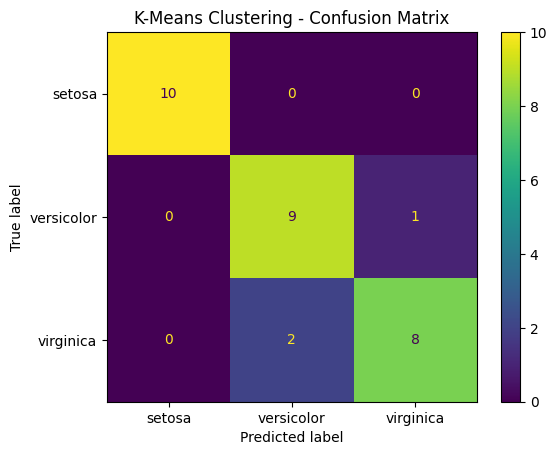

In [ ]:
# Classification using K-Means Clustering
# Prediction, Test Score and Confusion Matrix

import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Load Iris Dataset
iris = load_iris()

X = iris.data
y = iris.target

print("Classes:", iris.target_names)

# 2. Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. Create K-Means model
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# 4. Train K-Means model
kmeans.fit(X_train)

# Get cluster labels
train_clusters = kmeans.labels_

# 5. Map clusters to actual class labels
cluster_to_class = {}

for cluster in range(3):
    indices = np.where(train_clusters == cluster)[0]

    # Find the most frequent actual class in the cluster
    classes = y_train[indices]

    if len(classes) > 0:
        values, counts = np.unique(classes, return_counts=True)
        cluster_to_class[cluster] = values[np.argmax(counts)]

print("\nCluster Mapping:")
print(cluster_to_class)

# 6. Prediction on test data
test_clusters = kmeans.predict(X_test)

y_pred = np.array([
    cluster_to_class[cluster]
    for cluster in test_clusters
])

print("\nActual Values:")
print(y_test)

print("\nPredicted Values:")
print(y_pred)

# 7. Predict a new sample
new_sample = [[5.1, 3.5, 1.4, 0.2]]

new_cluster = kmeans.predict(new_sample)[0]
new_prediction = cluster_to_class[new_cluster]

print("\nNew Sample:", new_sample)
print("Predicted Class:", iris.target_names[new_prediction])

# 8. Test Score
test_score = accuracy_score(y_test, y_pred)

print("\nTest Score:", test_score)
print("Test Accuracy: {:.2f}%".format(test_score * 100))

# 9. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# 10. Display Confusion Matrix
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

display.plot()
plt.title("K-Means Clustering - Confusion Matrix")
plt.show()

Implement the Rule based method and test the same.

In [ ]:

def classify_student(marks, attendance):

    if marks >= 75 and attendance >= 75:
        return "Excellent"

    elif marks >= 60 and attendance >= 75:
        return "Good"

    elif marks >= 40 and attendance >= 60:
        return "Pass"

    else:
        return "Fail"

students = [
    ("Student 1", 85, 90),
    ("Student 2", 68, 80),
    ("Student 3", 45, 65),
    ("Student 4", 30, 50),
    ("Student 5", 78, 70)
]

print("Rule-Based Classification Results")
print("----------------------------------")

for name, marks, attendance in students:

    prediction = classify_student(marks, attendance)

    print("\nName:", name)
    print("Marks:", marks)
    print("Attendance:", attendance)
    print("Prediction:", prediction)

print("\n----------------------------------")
print("Testing New Student")

marks = float(input("Enter marks: "))
attendance = float(input("Enter attendance percentage: "))

result = classify_student(marks, attendance)

print("Predicted Class:", result)

Rule-Based Classification Results
----------------------------------

Name: Student 1
Marks: 85
Attendance: 90
Prediction: Excellent

Name: Student 2
Marks: 68
Attendance: 80
Prediction: Good

Name: Student 3
Marks: 45
Attendance: 65
Prediction: Pass

Name: Student 4
Marks: 30
Attendance: 50
Prediction: Fail

Name: Student 5
Marks: 78
Attendance: 70
Prediction: Pass

----------------------------------
Testing New Student
Enter marks: 52
Enter attendance percentage: 54
Predicted Class: Fail


 Implement the non-parametric Locally Weighted Regression
algorithm in order to fit data points. Select appropriate data set for
your experiment and draw graphs.

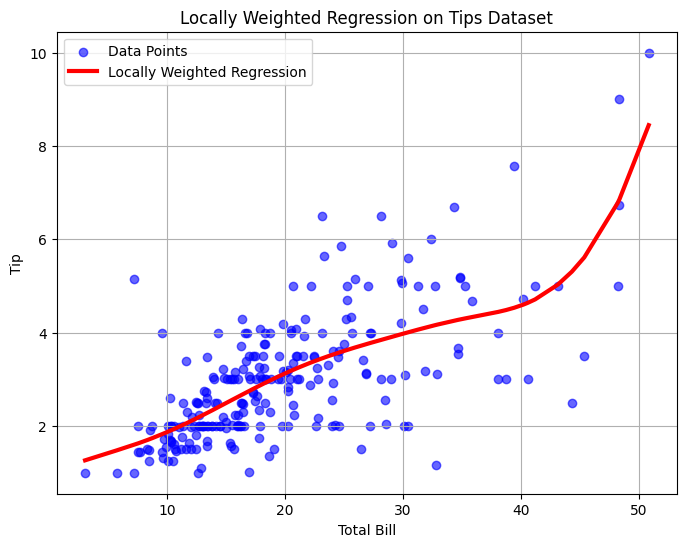

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

tips = sns.load_dataset("tips")

X = tips["total_bill"].values
y = tips["tip"].values

X_train = np.column_stack((np.ones(len(X)), X))

tau = 5

def locally_weighted_regression(x_query, X, y, tau):
    m = X.shape[0]

    W = np.eye(m)

    for i in range(m):
        diff = X[i][1] - x_query
        W[i, i] = np.exp(-(diff ** 2) / (2 * tau ** 2))

    theta = np.linalg.pinv(X.T @ W @ X) @ X.T @ W @ y

    return np.array([1, x_query]) @ theta

x_sorted = np.sort(X)
predictions = []

for point in x_sorted:
    predictions.append(
        locally_weighted_regression(point, X_train, y, tau)
    )

# Plot
plt.figure(figsize=(8,6))
plt.scatter(X, y, color="blue", alpha=0.6, label="Data Points")
plt.plot(x_sorted, predictions, color="red", linewidth=3,
         label="Locally Weighted Regression")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.title("Locally Weighted Regression on Tips Dataset")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import sys
import itertools
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
from google.colab import files # Added for file upload in Colab


# ----------------------------------------------------------------------
# 1-2. DATA LOADING AND DISCRETISATION
# ----------------------------------------------------------------------
def load_data(path):
    df = pd.read_csv(path, index_col=0)
    df = df.replace("?", np.nan).dropna().reset_index(drop=True)   # 6 rows have missing Ca/Thal
    df["Ca"] = df["Ca"].astype(float).astype(int)
    return df


def discretise(df):
    d = pd.DataFrame(index=df.index)
    d["Age"] = pd.cut(df.Age, [0, 45, 55, 65, 120], labels=["<45", "45-55", "55-65", ">65"])
    d["Sex"] = df.Sex.map({0: "female", 1: "male"})
    d["ChestPain"] = df.ChestPain
    d["RestBP"] = pd.cut(df.RestBP, [0, 120, 140, 400], labels=["normal", "elevated", "high"])
    d["Chol"] = pd.cut(df.Chol, [0, 200, 240, 1000], labels=["desirable", "borderline", "high"])
    d["Fbs"] = df.Fbs.map({0: "no", 1: "yes"})          # fasting sugar > 120 mg/dl
    d["RestECG"] = df.RestECG.map({0: "normal", 1: "st-t abn", 2: "LV hypertrophy"})
    d["MaxHR"] = pd.cut(df.MaxHR, [0, 120, 150, 300], labels=["low", "medium", "high"])
    d["ExAng"] = df.ExAng.map({0: "no", 1: "yes"})
    d["Oldpeak"] = pd.cut(df.Oldpeak, [-1, 0.5, 1.5, 10], labels=["low", "medium", "high"])
    d["Slope"] = df.Slope.map({1: "up", 2: "flat", 3: "down"})
    d["Ca"] = df.Ca.clip(upper=2).map({0: "0", 1: "1", 2: "2+"})   # vessels coloured by fluoroscopy
    d["Thal"] = df.Thal
    d["AHD"] = df.AHD                                    # Yes / No
    return d.astype(str)

EDGES = [
    ("Age", "RestBP"), ("Age", "Chol"), ("Age", "MaxHR"),
    ("Age", "AHD"), ("Sex", "AHD"), ("Sex", "Chol"),
    ("RestBP", "AHD"), ("Chol", "AHD"), ("Fbs", "AHD"),
    ("AHD", "ChestPain"), ("AHD", "ExAng"), ("AHD", "MaxHR"),
    ("AHD", "Oldpeak"), ("AHD", "RestECG"), ("AHD", "Ca"), ("AHD", "Thal"),
    ("Oldpeak", "Slope"), ("AHD", "Slope"),
]


# ----------------------------------------------------------------------
# Factor (table) utilities for exact inference
# ----------------------------------------------------------------------
class Factor:
    def __init__(self, vars_, table):
        self.vars = list(vars_)
        self.table = np.asarray(table, dtype=float)

    def multiply(self, other, card):
        allv = self.vars + [v for v in other.vars if v not in self.vars]
        return Factor(allv, self._expand(allv) * other._expand(allv))

    def _expand(self, allv):
        # broadcast this factor's table to the axis order of allv
        shape = [self.table.shape[self.vars.index(v)] if v in self.vars else 1 for v in allv]
        order = [v for v in allv if v in self.vars]
        perm = [self.vars.index(v) for v in order]
        return self.table.transpose(perm).reshape(shape)

    def marginalise(self, var):
        ax = self.vars.index(var)
        return Factor([v for v in self.vars if v != var], self.table.sum(axis=ax))

    def reduce(self, var, idx):
        if var not in self.vars:
            return self
        ax = self.vars.index(var)
        return Factor([v for v in self.vars if v != var], np.take(self.table, idx, axis=ax))


class BayesianNetwork:
    def __init__(self, edges):
        self.edges = edges
        self.nodes = sorted({n for e in edges for n in e})
        self.parents = {n: [p for p, c in edges if c == n] for n in self.nodes}
        self._check_acyclic()

    def _check_acyclic(self):
        seen, done = set(), set()
        def visit(n):
            if n in done: return
            if n in seen: raise ValueError("Graph has a cycle at " + n)
            seen.add(n)
            for p in self.parents[n]: visit(p)
            done.add(n)
        for n in self.nodes: visit(n)

    def fit(self, data, alpha=1.0):
        """MLE with Laplace (Dirichlet-alpha) smoothing -> one CPT per node."""
        self.states = {n: sorted(data[n].unique()) for n in self.nodes}
        self.cpt = {}
        for n in self.nodes:
            ps = self.parents[n]
            shape = [len(self.states[p]) for p in ps] + [len(self.states[n])]
            counts = np.full(shape, alpha)
            idx = [data[c].map({s: i for i, s in enumerate(self.states[c])}).values for c in ps + [n]]
            np.add.at(counts, tuple(idx), 1)
            self.cpt[n] = Factor(ps + [n], counts / counts.sum(axis=-1, keepdims=True))
        return self

    def query(self, target, evidence=None):
        """P(target | evidence) by variable elimination."""
        evidence = {k: v for k, v in (evidence or {}).items() if k != target}
        factors = []
        for n in self.nodes:
            f = self.cpt[n]
            for var, val in evidence.items():
                f = f.reduce(var, self.states[var].index(val))
            factors.append(f)
        hidden = [n for n in self.nodes if n != target and n not in evidence]
        # greedy min-size elimination order
        while hidden:
            def cost(v):
                vs = {u for f in factors if v in f.vars for u in f.vars}
                return np.prod([len(self.states[u]) for u in vs])
            v = min(hidden, key=cost); hidden.remove(v)
            rel = [f for f in factors if v in f.vars]
            factors = [f for f in factors if v not in f.vars]
            if rel:
                prod = rel[0]
                for f in rel[1:]: prod = prod.multiply(f, None)
                factors.append(prod.marginalise(v))
        res = factors[0]
        for f in factors[1:]: res = res.multiply(f, None)
        p = res.table / res.table.sum()
        return dict(zip(self.states[target], p))

    def predict(self, row, target="AHD"):
        ev = {k: v for k, v in row.items() if k in self.nodes and k != target}
        return self.query(target, ev)

def cross_validate(data, folds=5):
    X_cols = [c for c in data.columns if c != "AHD"]
    y = data["AHD"].values
    accs, probs_all, y_all, pred_all = [], [], [], []
    for tr, te in StratifiedKFold(folds, shuffle=True, random_state=42).split(data, y):
        bn = BayesianNetwork(EDGES).fit(data.iloc[tr])
        for _, row in data.iloc[te].iterrows():
            p = bn.predict(row[X_cols].to_dict())
            probs_all.append(p["Yes"]); pred_all.append("Yes" if p["Yes"] >= .5 else "No")
        y_all += list(y[te])
    print(f"\n{folds}-fold cross-validation")
    print(f"  Accuracy : {accuracy_score(y_all, pred_all):.3f}")
    print(f"  ROC AUC  : {roc_auc_score(np.array(y_all) == 'Yes', probs_all):.3f}")
    cm = confusion_matrix(y_all, pred_all, labels=["No", "Yes"])
    print("  Confusion matrix (rows=actual, cols=predicted; No, Yes):")
    print("   ", cm[0], "\n   ", cm[1])
    tn, fp, fn, tp = cm.ravel()
    print(f"  Sensitivity: {tp/(tp+fn):.3f}   Specificity: {tn/(tn+fp):.3f}")


# ----------------------------------------------------------------------
# 7. DIAGNOSIS DEMONSTRATION
# ----------------------------------------------------------------------
def show(bn, title, evidence):
    p = bn.query("AHD", evidence)["Yes"]
    print(f"\n{title}")
    for k, v in evidence.items():
        print(f"   {k:<10}= {v}")
    print(f"   --> P(Heart disease) = {p:.1%}   => "
          f"{'HIGH RISK / likely disease' if p >= .5 else 'LOW RISK / likely healthy'}")


def demo(bn, data):
    print("\n" + "=" * 62)
    print("PRIOR PROBABILITY OF HEART DISEASE (no evidence)")
    print("=" * 62)
    print("Prior P(AHD = Yes) from the model:", round(bn.query('AHD')['Yes'], 3))

    print("\n" + "=" * 62)
    print("WHAT-IF DIAGNOSIS: evidence added step by step")
    print("=" * 62)
    ev = {"Age": "55-65", "Sex": "male"}
    show(bn, "Step 1: demographics only", dict(ev))
    ev["ChestPain"] = "asymptomatic"; show(bn, "Step 2: + asymptomatic chest pain", dict(ev))
    ev["ExAng"] = "yes";              show(bn, "Step 3: + exercise-induced angina", dict(ev))
    ev["Thal"] = "reversable";        show(bn, "Step 4: + reversible thalassemia defect", dict(ev))
    ev["Ca"] = "2+";                  show(bn, "Step 5: + 2 or more major vessels coloured", dict(ev))

    show(bn, "Contrasting low-risk patient",
         {"Age": "<45", "Sex": "female", "ChestPain": "nonanginal", "ExAng": "no",
          "Thal": "normal", "Ca": "0", "MaxHR": "high"})

    print("\n" + "=" * 62)
    print("DIAGNOSIS OF 8 PATIENTS FROM THE DATA SET")
    print("=" * 62)
    print(f"{'#':>4} {'Age':>6} {'Sex':>6} {'ChestPain':>13} {'P(disease)':>11} {'Predicted':>10} {'Actual':>7}")
    for i in data.sample(8, random_state=3).index:
        row = data.loc[i]
        p = bn.predict(row.drop("AHD").to_dict())["Yes"]
        print(f"{i:>4} {row.Age:>6} {row.Sex:>6} {row.ChestPain:>13} {p:>11.1%} "
              f"{('Yes' if p >= .5 else 'No'):>10} {row.AHD:>7}")


def main():
    default_filename = "Heart.csv"
    path = default_filename

    print(f"Please upload the '{default_filename}' file for Bayesian Network analysis.")
    uploaded = files.upload()

    if uploaded:
        path = list(uploaded.keys())[0]
        print(f"Using uploaded file: {path}")
    else:
        print("No file was uploaded. Exiting.")
        return

    raw = load_data(path)
    data = discretise(raw)
    print(f"Loaded {len(raw)} complete patient records; "
          f"{(data.AHD == 'Yes').mean():.1%} have heart disease.")
    print("\nNetwork structure (parent -> child):")
    for p, c in EDGES: print(f"   {p} -> {c}")

    cross_validate(data)
    bn = BayesianNetwork(EDGES).fit(data)      # final model on all data
    demo(bn, data)


if __name__ == "__main__":
    main()

Please upload the 'Heart.csv' file for Bayesian Network analysis.


Saving Heart.csv to Heart.csv
Using uploaded file: Heart.csv
Loaded 297 complete patient records; 46.1% have heart disease.

Network structure (parent -> child):
   Age -> RestBP
   Age -> Chol
   Age -> MaxHR
   Age -> AHD
   Sex -> AHD
   Sex -> Chol
   RestBP -> AHD
   Chol -> AHD
   Fbs -> AHD
   AHD -> ChestPain
   AHD -> ExAng
   AHD -> MaxHR
   AHD -> Oldpeak
   AHD -> RestECG
   AHD -> Ca
   AHD -> Thal
   Oldpeak -> Slope
   AHD -> Slope

5-fold cross-validation
  Accuracy : 0.835
  ROC AUC  : 0.910
  Confusion matrix (rows=actual, cols=predicted; No, Yes):
    [141  19] 
    [ 30 107]
  Sensitivity: 0.781   Specificity: 0.881

PRIOR PROBABILITY OF HEART DISEASE (no evidence)
Prior P(AHD = Yes) from the model: 0.492

WHAT-IF DIAGNOSIS: evidence added step by step

Step 1: demographics only
   Age       = 55-65
   Sex       = male
   --> P(Heart disease) = 65.6%   => HIGH RISK / likely disease

Step 2: + asymptomatic chest pain
   Age       = 55-65
   Sex       = male
   ChestP